In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os

In [12]:
import sys
import importlib

# --- FIX: AUTORELOAD FOR JUPYTER ---
# These lines ensure that when you save changes to logistic_regression.py, 
# the notebook will automatically reload the new code.
%load_ext autoreload
%autoreload 2
# -----------------------------------

proc_lib='processing_utils'

# Now importing DH_OBJ from the logistic_regression package
try:
    # 1. Check if the module is already loaded (cached)
    if proc_lib in sys.modules:
        print(f"Module {proc_lib} found in cache. Forcing reload...")
        importlib.reload(sys.modules['processing_utils'])
    
    # 2. Perform the import (this will use the reloaded or new version)
    import processing_utils as proc
except ImportError as e:
    print(f"\n[ERROR] Import failed. Ensure your {proc_lib} file are correctly structured.")
    print(f"Details: {e}")
    sys.exit(1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Module processing_utils found in cache. Forcing reload...


# 0. Inputs

In [13]:
# Arguments. Test purpose only
input_dir = "/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29"
test_type = "default"
channels = [0, 1]
nominal_period_us = 1000000
duration = 60.0

# Create array of data to use in the loop
plots = []
for load_type in ["idle", "load"]:
    for channel in channels:
        plots.append(proc.Plot_obj(input_dir, test_type, load_type, channel, nominal_period_us))

Successfully matched graph channel 0 to column 'Channel 0'
Successfully matched graph channel 1 to column 'Channel 1'
Successfully matched graph channel 0 to column 'Channel 0'
Successfully matched graph channel 1 to column 'Channel 1'


# 1. Jitter plus

In [14]:
# Separate to idle and load
plots_idle = [obj for obj in plots if obj.load_type == "idle"]
phase_idle = proc.perform_phase_shift_analysis(plots_idle[0].result['edges_rise'], plots_idle[1].result['edges_rise'], nominal_period_us)

plots_load = [obj for obj in plots if obj.load_type == "load"]
phase_load = proc.perform_phase_shift_analysis(plots_load[0].result['edges_rise'], plots_load[1].result['edges_rise'], nominal_period_us)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_rise_0.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_fall_0.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_rise_fall_0.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_rise_1.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_fall_1.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_rise_fall_1.png'


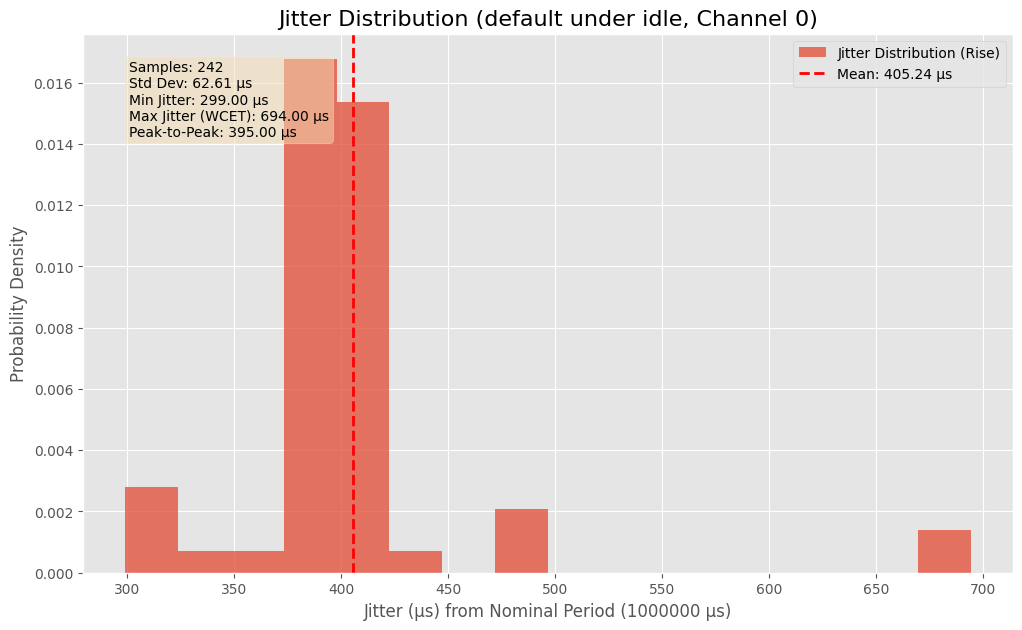

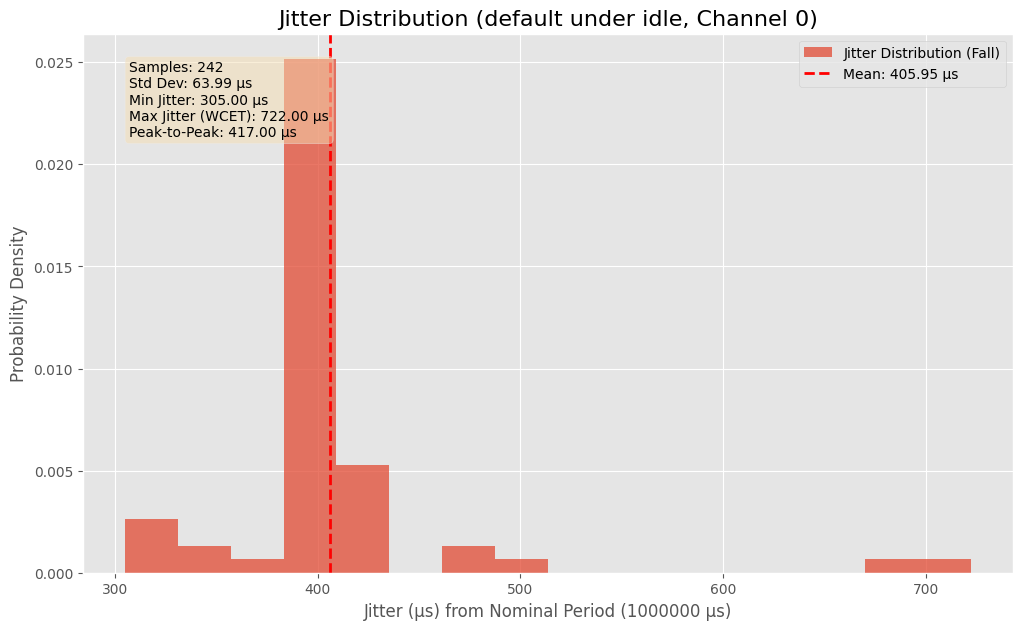

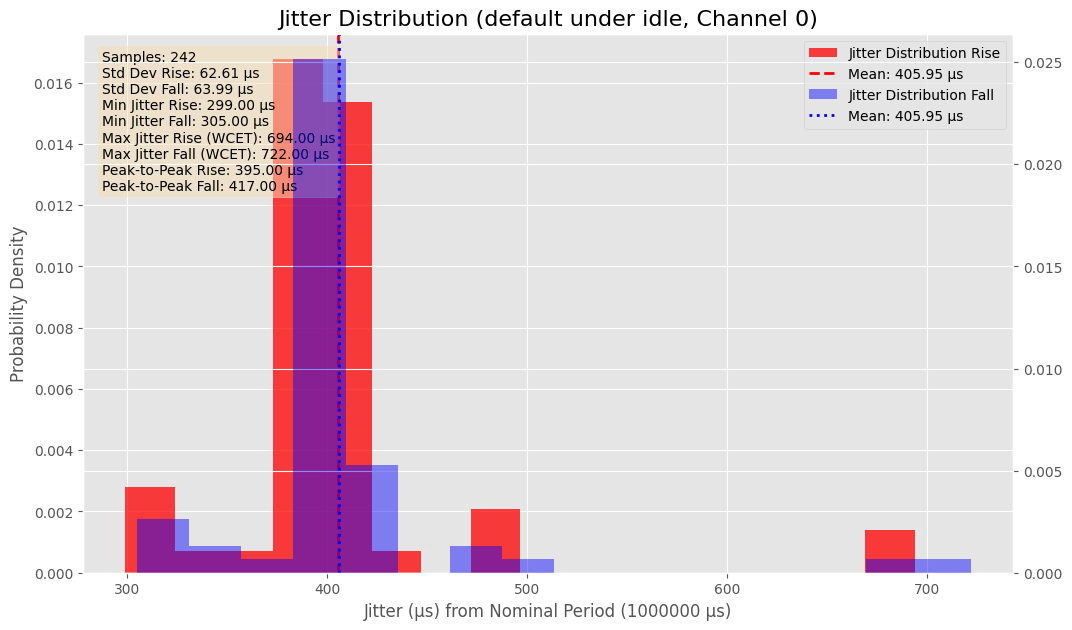

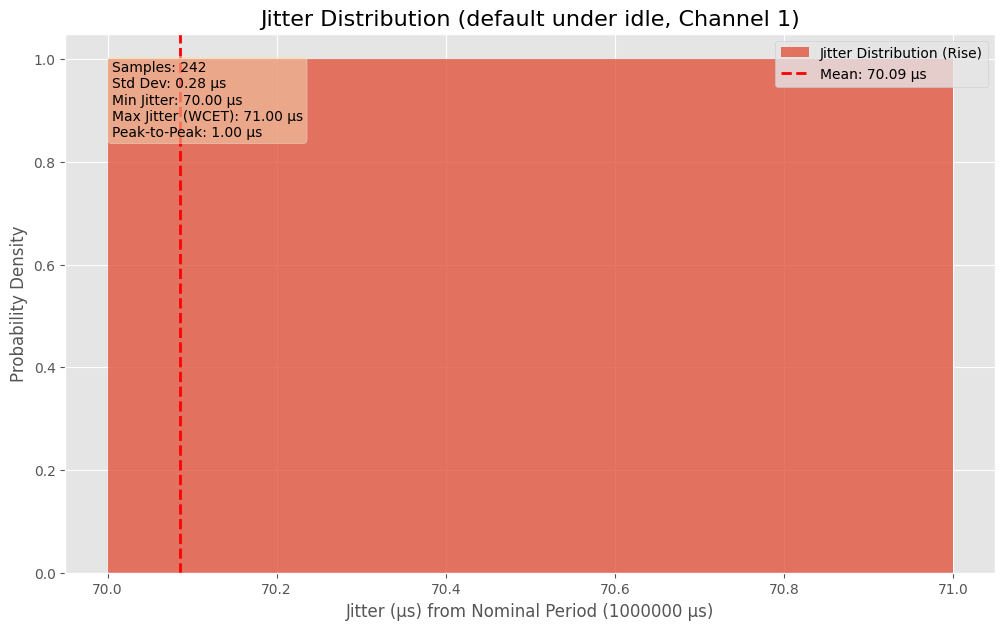

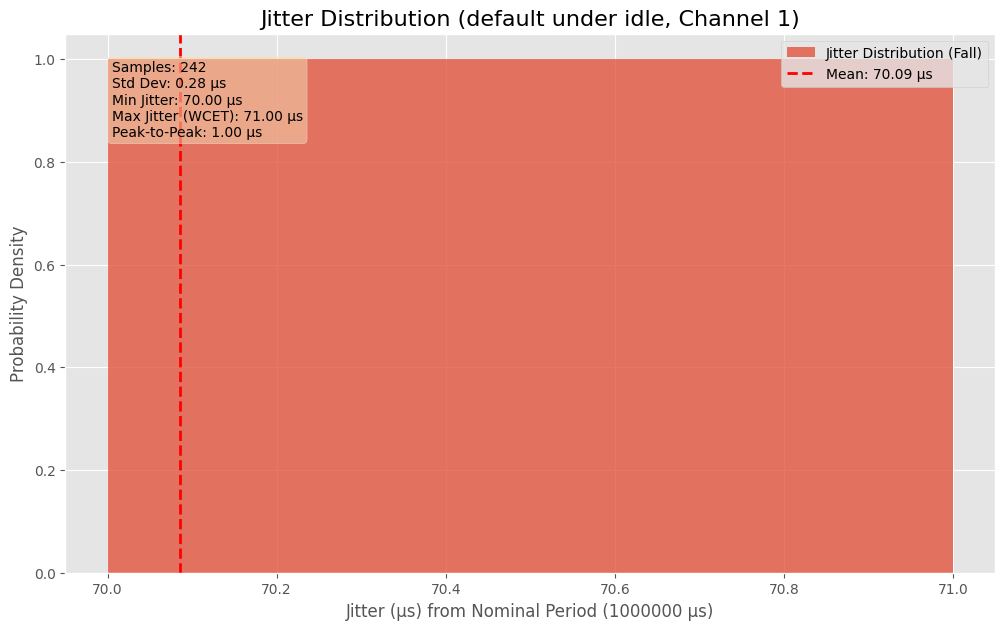

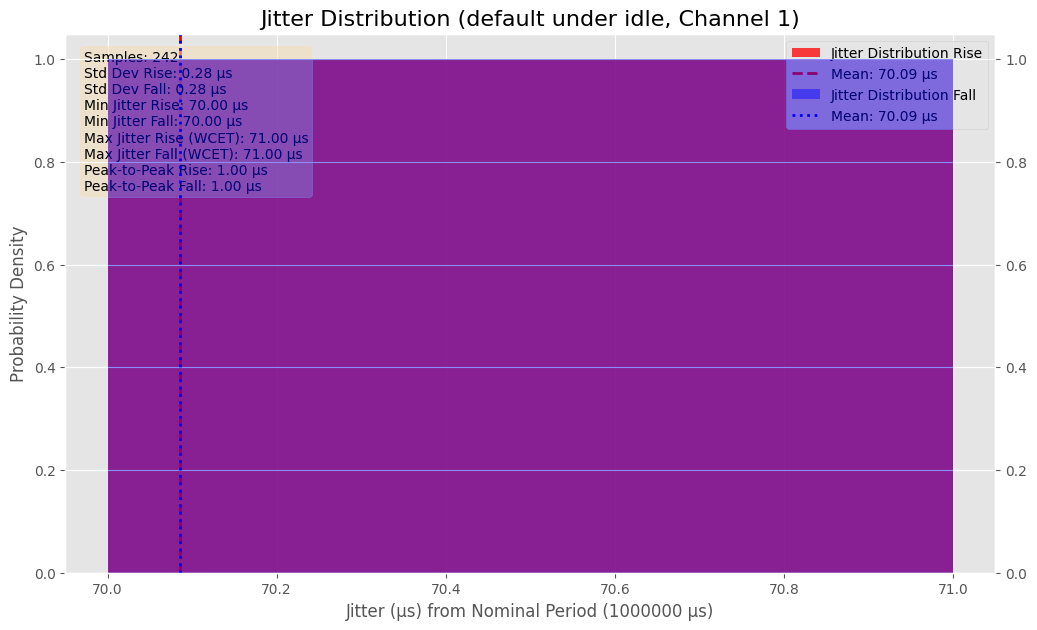

In [15]:
# Plot histogram idle
for plot in plots_idle:
    proc.plot_histogram_rise(plot.result, plot.jitter_title, proc.plot_path(plot, "histogram", "rise"))
    proc.plot_histogram_fall(plot.result, plot.jitter_title, proc.plot_path(plot, "histogram", "fall"))
    proc.plot_histogram_combined(plot.result, plot.jitter_title, proc.plot_path(plot, "histogram", "rise_fall"))
    

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_load_rise_0.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_load_fall_0.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_load_rise_fall_0.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_load_rise_1.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_load_fall_1.png'
Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_load_rise_fall_1.png'


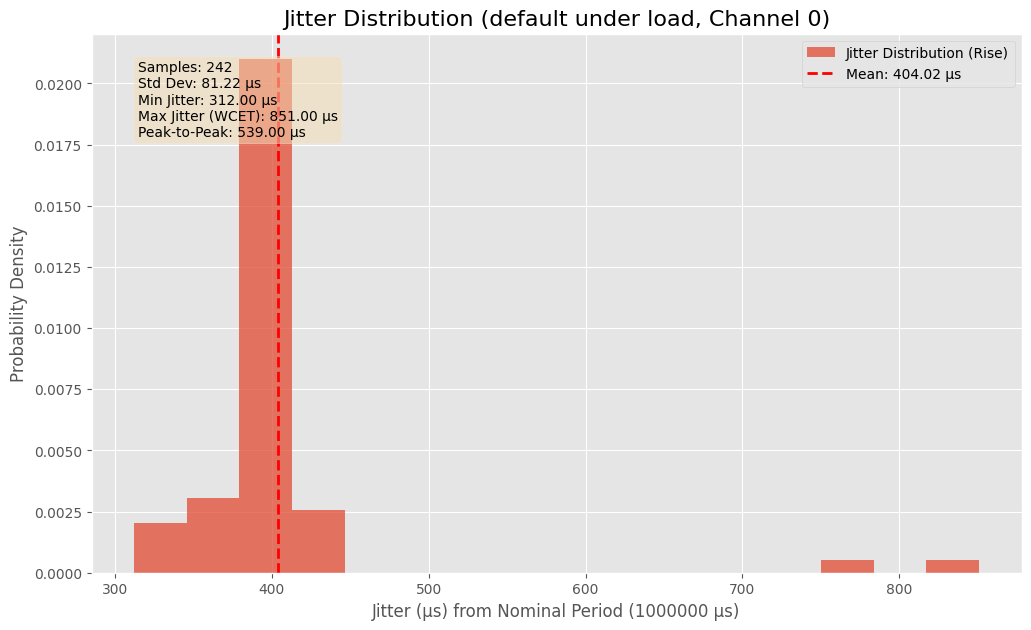

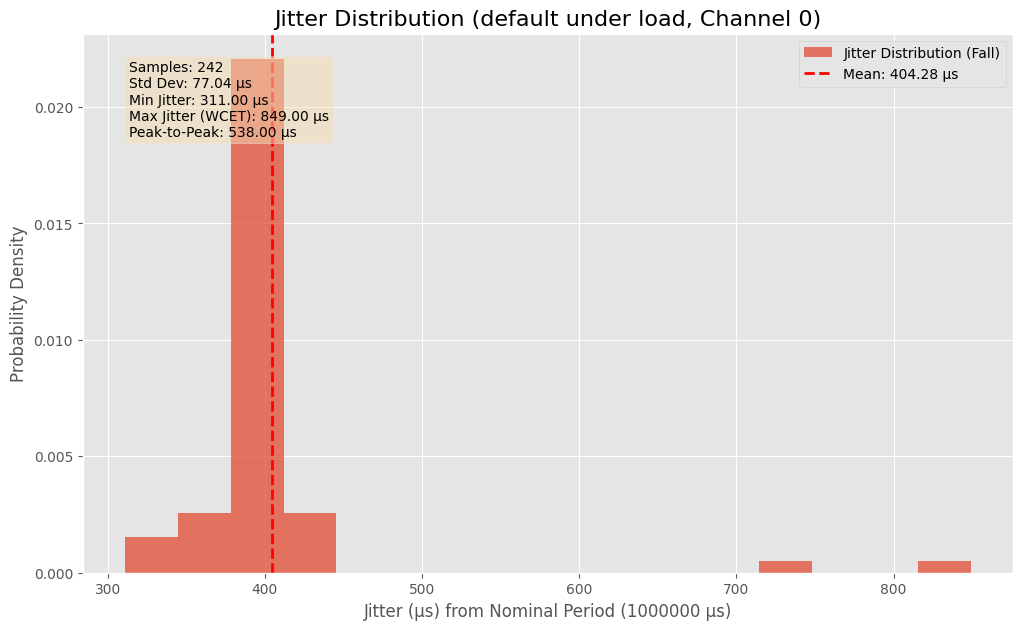

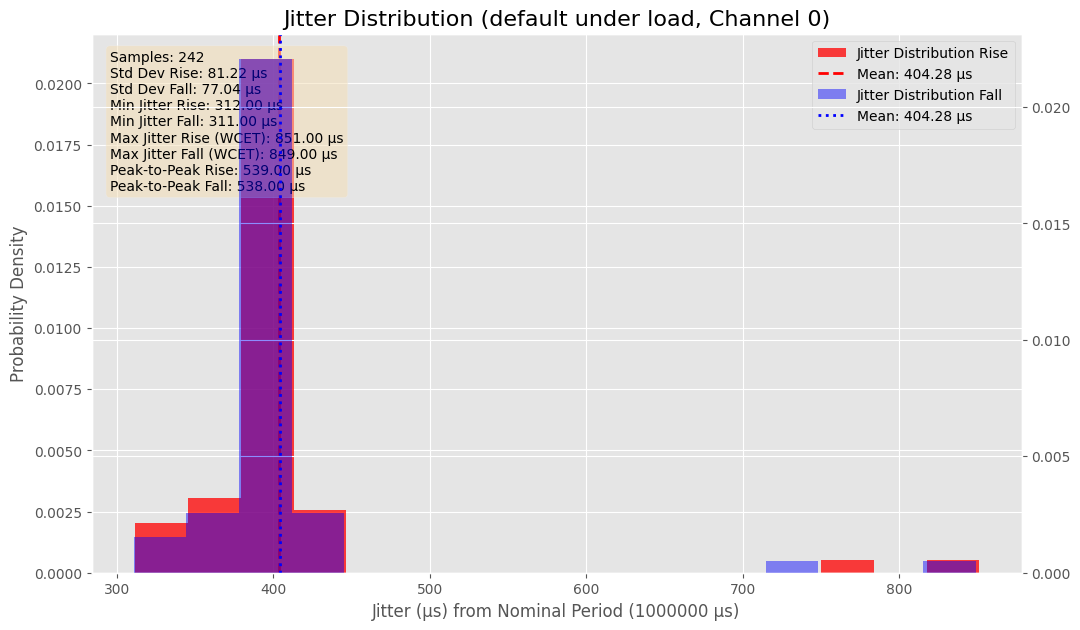

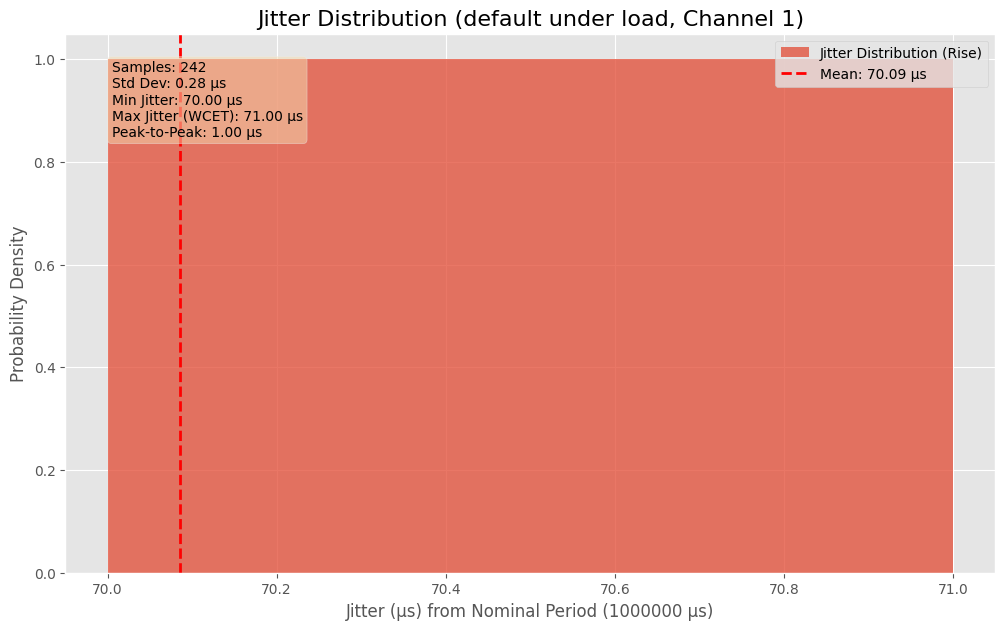

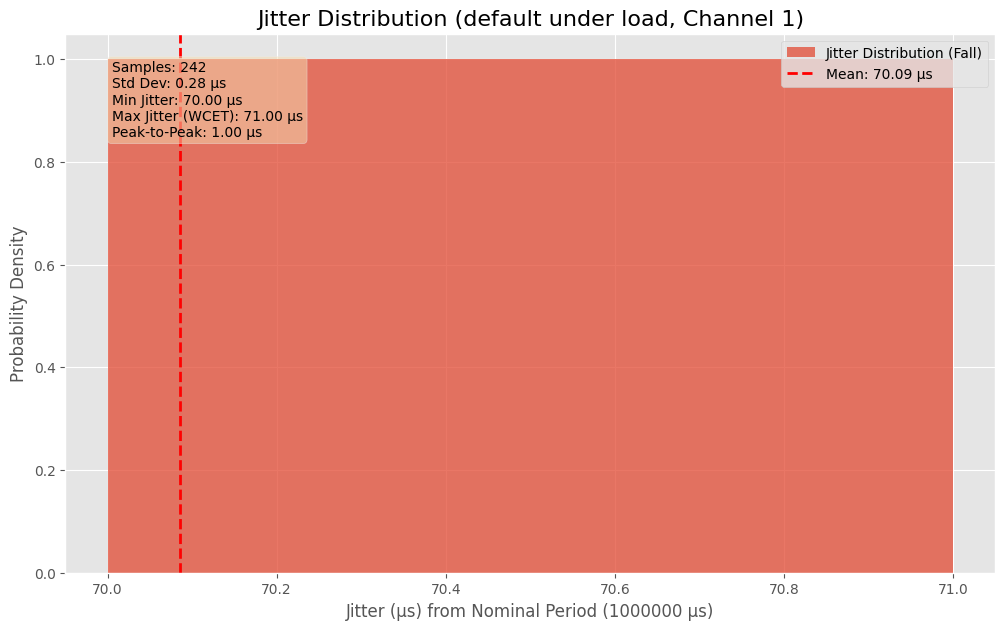

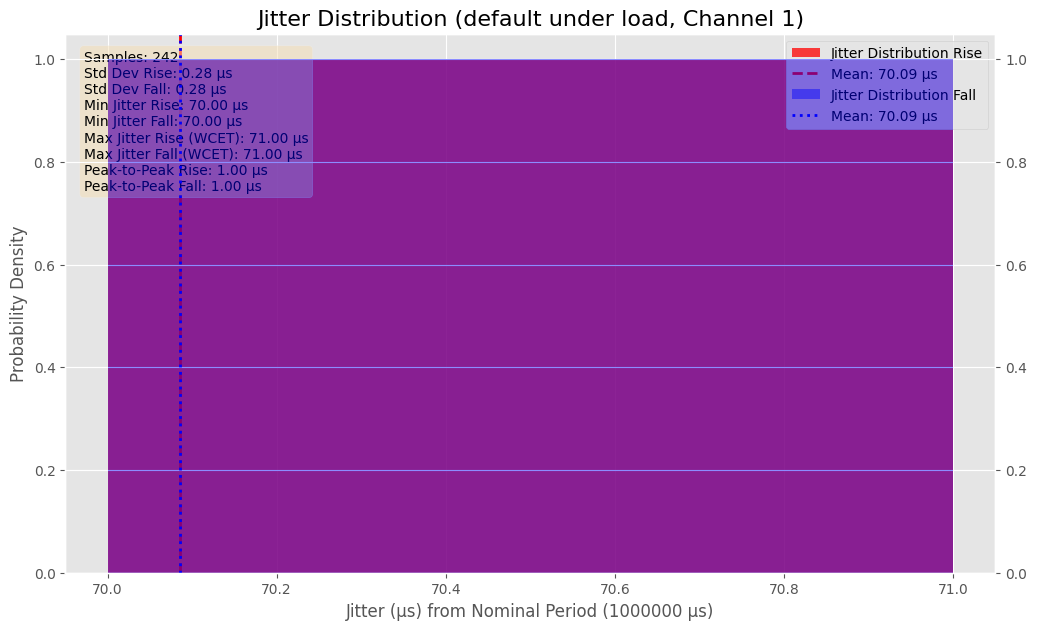

In [16]:
# Plot histogram load
for plot in plots_load:
    proc.plot_histogram_rise(plot.result, plot.jitter_title, proc.plot_path(plot, "histogram", "rise"))
    proc.plot_histogram_fall(plot.result, plot.jitter_title, proc.plot_path(plot, "histogram", "fall"))
    proc.plot_histogram_combined(plot.result, plot.jitter_title, proc.plot_path(plot, "histogram", "rise_fall"))

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_phase_shift_default_idle.png'


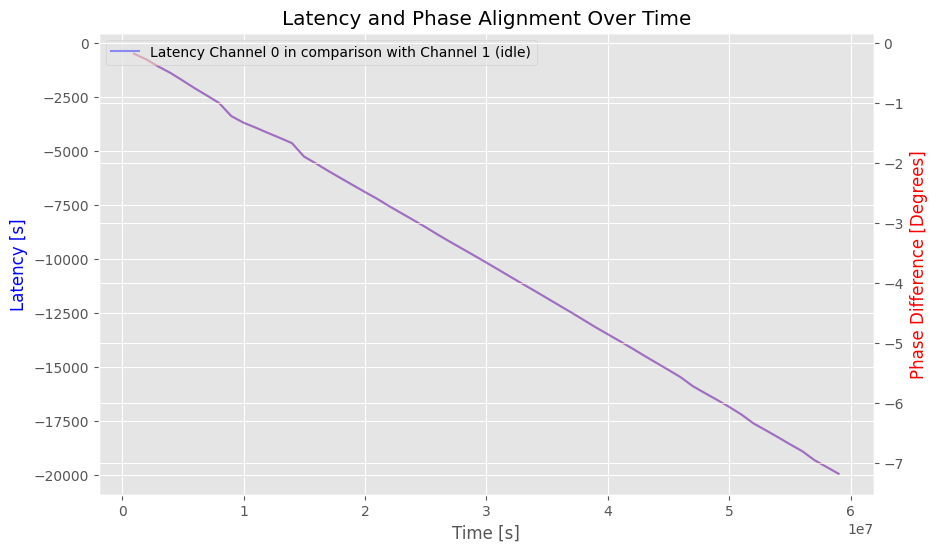

In [17]:
label = f"Latency Channel {plots_idle[0].channel} in comparison with Channel {plots_idle[1].channel} (idle)"
proc.plot_phase_shift_combined(phase_idle, label, proc.plot_path(plots_idle[0], "phase_shift", "", combined=True))

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_phase_shift_default_load.png'


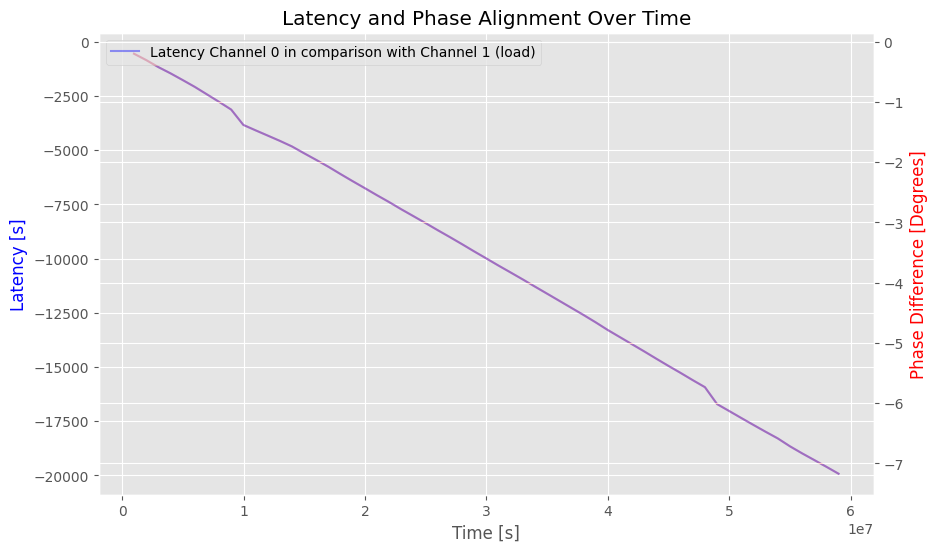

In [18]:
label = f"Latency Channel {plots_load[0].channel} in comparison with Channel {plots_load[1].channel} (load)"
proc.plot_phase_shift_combined(phase_load, label, proc.plot_path(plots_load[0], "phase_shift", "", combined=True))

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_duty_cycle_default_idle.png'


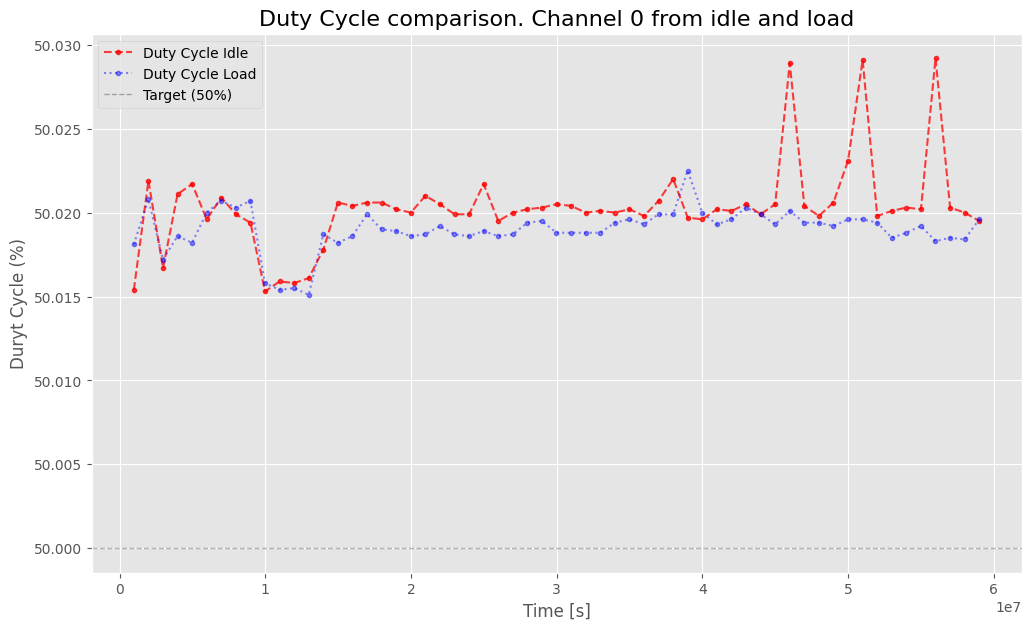

In [19]:
title = "Duty Cycle comparison. Channel 0 from idle and load"
proc.plot_duty_cycle_combined(plots_idle[0].result, plots_load[0].result, title, proc.plot_path(plots_idle[0], "duty_cycle", "",combined=True))

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_duty_cycle_default_idle.png'


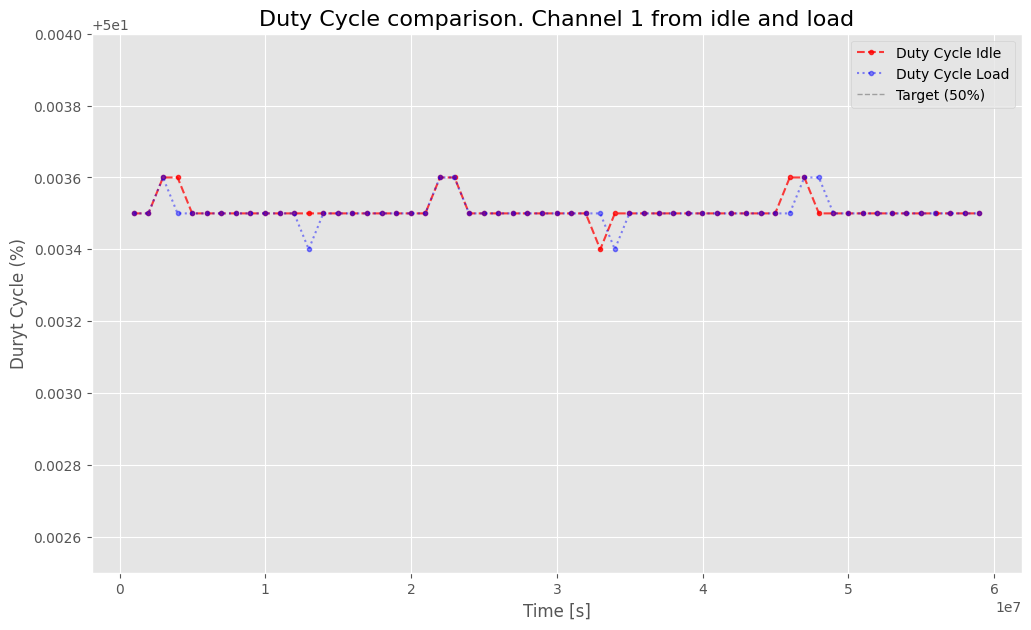

In [20]:
title = "Duty Cycle comparison. Channel 1 from idle and load"
proc.plot_duty_cycle_combined(plots_idle[1].result, plots_load[1].result, title, proc.plot_path(plots_idle[1], "duty_cycle", "",combined=True), y_lim=(50.0025, 50.004))